# 🛡️ SecureMind AI — Phishing Email Model Training Pipeline

This notebook uses the cleaned phishing dataset to train models mimicking the pipeline used in the CICIDS2017 workflow:
1. Load cleaned data
2. Train/Validation/Test split (stratified)
3. TF-IDF Vectorization (instead of Standard Scaling)
4. Train Decision Tree and Random Forest
5. Evaluate on Validation and Test sets

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')
print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## 2. Load Cleaned Dataset

In [2]:
DATA_PATH = os.path.join('../../data_output/phishing_cleaned.csv')
data = pd.read_csv(DATA_PATH)
# Ensure all text is string and drop any unexpected NaNs
data = data.dropna()
data['text'] = data['text'].astype(str)

print(f'✅ Dataset loaded: {data.shape}')
data.head()

✅ Dataset loaded: (82486, 2)


,text,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [3]:
TARGET_COL = 'label'
LABEL_NAMES = {0: 'Legitimate', 1: 'Phishing'}

## 3. Train / Validation / Test Split (70/15/15)

In [4]:
X = data['text']
y = data[TARGET_COL]

# Stage 1: split into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Stage 2: split temp into validation (50% of 30% = 15%) and test (50% of 30% = 15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

del X_temp, y_temp  # free memory

print(f'✅ Train set:      {X_train.shape[0]:>10,} samples  ({X_train.shape[0]/len(data)*100:.1f}%)')
print(f'✅ Validation set: {X_val.shape[0]:>10,} samples  ({X_val.shape[0]/len(data)*100:.1f}%)')
print(f'✅ Test set:       {X_test.shape[0]:>10,} samples  ({X_test.shape[0]/len(data)*100:.1f}%)')

✅ Train set:          57,740 samples  (70.0%)
✅ Validation set:     12,373 samples  (15.0%)
✅ Test set:           12,373 samples  (15.0%)


## 4. Text Vectorization (TF-IDF)

In [5]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

# Fit on train ONLY, transform all sets to prevent data leakage
start_time = time.time()
X_train_vec = vectorizer.fit_transform(X_train)
print(f'✅ Fit and transformed training data in {time.time() - start_time:.2f}s')

X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

print(f'✅ Vectorization complete. Vocabulary size: {len(vectorizer.get_feature_names_out())}')

✅ Fit and transformed training data in 10.75s


✅ Vectorization complete. Vocabulary size: 5000


## 5. Model Training & Validation

In [6]:
def train_and_evaluate(name, model, X_tr, y_tr, X_v, y_v, label_names):
    """Train a model, evaluate on validation set, return results dict."""
    print(f'\n{"="*60}')
    print(f'  Training: {name}')
    print(f'{"="*60}')

    start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start
    print(f'  ⏱️  Training time: {train_time:.2f}s')

    # Predict on validation
    start = time.time()
    y_pred = model.predict(X_v)
    pred_time = time.time() - start

    acc = accuracy_score(y_v, y_pred)
    print(f'  ✅ Validation Accuracy: {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  ⏱️  Prediction time:  {pred_time:.2f}s')

    # Classification report
    target_names = [label_names[i] for i in sorted(label_names.keys())]
    report = classification_report(
        y_v, y_pred,
        target_names=target_names,
        zero_division=0
    )
    print(f'\n{report}')

    return {
        'name': name,
        'model': model,
        'accuracy': acc,
        'train_time': train_time,
        'pred_time': pred_time,
        'y_pred': y_pred,
    }

print('✅ Helper function defined')

✅ Helper function defined


In [7]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=20)

dt_results = train_and_evaluate(
    'Decision Tree', dt_model,
    X_train_vec, y_train,
    X_val_vec, y_val,
    LABEL_NAMES
)


  Training: Decision Tree


  ⏱️  Training time: 12.33s
  ✅ Validation Accuracy: 0.9440  (94.40%)
  ⏱️  Prediction time:  0.01s

              precision    recall  f1-score   support

  Legitimate       0.97      0.91      0.94      5939
    Phishing       0.93      0.97      0.95      6434

    accuracy                           0.94     12373
   macro avg       0.95      0.94      0.94     12373
weighted avg       0.95      0.94      0.94     12373



In [8]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, n_jobs=-1, random_state=42)

rf_results = train_and_evaluate(
    'Random Forest', rf_model,
    X_train_vec, y_train,
    X_val_vec, y_val,
    LABEL_NAMES
)


  Training: Random Forest


  ⏱️  Training time: 8.26s
  ✅ Validation Accuracy: 0.9556  (95.56%)
  ⏱️  Prediction time:  0.15s

              precision    recall  f1-score   support

  Legitimate       0.98      0.92      0.95      5939
    Phishing       0.93      0.98      0.96      6434

    accuracy                           0.96     12373
   macro avg       0.96      0.95      0.96     12373
weighted avg       0.96      0.96      0.96     12373



## 6. Test Set Final Evaluation

🏅 Evaluating Best Model (Random Forest) on Held-out TEST Set:


  ⏱️  Test Prediction time: 0.17s
  🎯  Test Accuracy: 0.9561 (95.61%)
              precision    recall  f1-score   support

  Legitimate       0.98      0.93      0.95      5940
    Phishing       0.94      0.98      0.96      6433

    accuracy                           0.96     12373
   macro avg       0.96      0.95      0.96     12373
weighted avg       0.96      0.96      0.96     12373



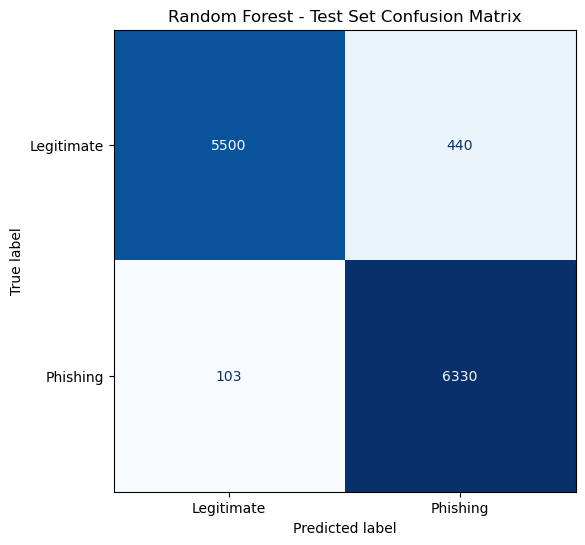

In [9]:
best_model = rf_model if rf_results['accuracy'] > dt_results['accuracy'] else dt_model
best_model_name = rf_results['name'] if rf_results['accuracy'] > dt_results['accuracy'] else dt_results['name']

print(f'🏅 Evaluating Best Model ({best_model_name}) on Held-out TEST Set:')
start = time.time()
y_test_pred = best_model.predict(X_test_vec)
print(f'  ⏱️  Test Prediction time: {time.time() - start:.2f}s')

test_acc = accuracy_score(y_test, y_test_pred)
print(f'  🎯  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

target_names = [LABEL_NAMES[i] for i in sorted(LABEL_NAMES.keys())]
print(classification_report(y_test, y_test_pred, target_names=target_names))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
plt.title(f'{best_model_name} - Test Set Confusion Matrix')
plt.show()

## 7. Export Artifacts

In [10]:
os.makedirs('../../models/Phishing', exist_ok=True)

model_path = '../../models/Phishing/best_phishing_model.pkl'
vectorizer_path = '../../models/Phishing/tfidf_vectorizer.pkl'
label_map_path = '../../models/Phishing/label_map.pkl'

joblib.dump(best_model, model_path)
joblib.dump(vectorizer, vectorizer_path)
joblib.dump(LABEL_NAMES, label_map_path)

print(f'✅ Best model ({best_model_name}) saved to {model_path}')
print(f'✅ TF-IDF vectorizer saved to {vectorizer_path}')
print(f'✅ Label map saved to {label_map_path}')

# Save split datasets
os.makedirs('../../data_output/Phishing', exist_ok=True)
pd.DataFrame({'text': X_train, 'label': y_train}).to_csv('../../data_output/Phishing/train.csv', index=False)
pd.DataFrame({'text': X_val, 'label': y_val}).to_csv('../../data_output/Phishing/val.csv', index=False)
pd.DataFrame({'text': X_test, 'label': y_test}).to_csv('../../data_output/Phishing/test.csv', index=False)
print('✅ Split datasets saved to ../../data_output/Phishing/')

✅ Best model (Random Forest) saved to ../../models/Phishing/best_phishing_model.pkl
✅ TF-IDF vectorizer saved to ../../models/Phishing/tfidf_vectorizer.pkl
✅ Label map saved to ../../models/Phishing/label_map.pkl


✅ Split datasets saved to ../../data_output/Phishing/
